# Example 2: Corpus-Level Population Statistics and Morpho-Kinematic Diversity

**High-z Kinematic Corpus Z1 — EPS Research, Flynn D.C. (2026)**

This notebook demonstrates corpus-level filtering and population analysis using the  
flat CSV. No per-ring data is required — all statistics come from the summary fields  
present for all 31 galaxies.

We show:
- Morpho-kinematic class fractions (ROT / MER / DIS / UNC)
- Redshift distribution across the ALPINE z = 4.3–5.7 window
- v/σ distribution for the 8 tier-1 rotators
- Wisnioski et al. (2015) disk criteria heatmap across all rotators
- z > 5 subsample breakdown and high-σ population

**Corpus:** Flynn (2026), Zenodo DOI: [pending]  
**Source data:** Jones et al. (2021), MNRAS; Le Fèvre et al. (2020), A&A 643, A1  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'high_z_kinematic_corpus_Z1.json': 'https://zenodo.org/records/21327061/files/high_z_kinematic_corpus_Z1.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import csv
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter

# ── Load flat CSV ─────────────────────────────────────────────────────────────
galaxies_csv = []
with open('high_z_kinematic_corpus_Z1_flat.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        galaxies_csv.append(row)

# ── Also load full JSON for W15 data and per-ring fields ─────────────────────
with open('high_z_kinematic_corpus_Z1.json') as f:
    corpus = json.load(f)
by_name = {g['galaxy']: g for g in corpus['galaxies']}

print(f"CSV rows loaded:   {len(galaxies_csv)}")
print(f"JSON galaxies:     {len(corpus['galaxies'])}")

CSV rows loaded:   31
JSON galaxies:     31


In [3]:
# ── Parse key fields ──────────────────────────────────────────────────────────
classes   = [r['class_jones2021'] for r in galaxies_csv]
redshifts = [float(r['redshift']) for r in galaxies_csv]
tiers     = [int(r['quality_tier']) for r in galaxies_csv]

class_counts = Counter(classes)
n_total      = len(galaxies_csv)
n_tier1      = sum(1 for t in tiers if t == 1)
n_tier2      = sum(1 for t in tiers if t == 2)
n_z5         = sum(1 for z in redshifts if z > 5.0)

print("Class breakdown:")
for cls in ['ROT','MER','DIS','UNC']:
    n = class_counts[cls]
    print(f"  {cls}: {n:2d}  ({100*n/n_total:.1f}%)")
print(f"\nQuality tiers:  Tier 1 = {n_tier1}, Tier 2 = {n_tier2}")
print(f"z > 5 subsample: {n_z5} / {n_total} galaxies")
print(f"Redshift range:  z = {min(redshifts):.4f} -- {max(redshifts):.4f}")

Class breakdown:
  ROT:  8  (25.8%)
  MER:  5  (16.1%)
  DIS:  3  (9.7%)
  UNC: 15  (48.4%)

Quality tiers:  Tier 1 = 8, Tier 2 = 23
z > 5 subsample: 9 / 31 galaxies
Redshift range:  z = 4.2605 -- 5.6773


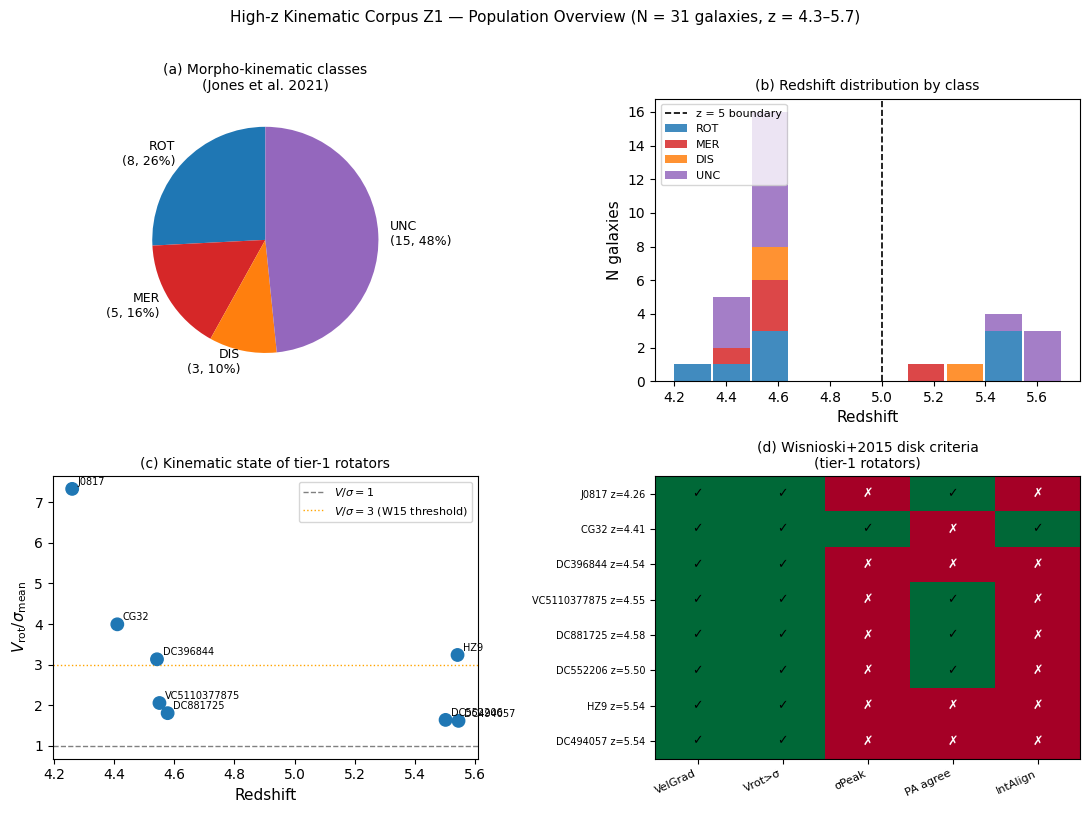

Saved: fig_hz_nb2_population.png


In [4]:
# ── Figure: 4-panel population overview ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(
    'High-z Kinematic Corpus Z1 — Population Overview (N = 31 galaxies, z = 4.3–5.7)',
    fontsize=11, y=1.01)

CLASS_COLORS = {'ROT': '#1f77b4', 'MER': '#d62728', 'DIS': '#ff7f0e', 'UNC': '#9467bd'}

# ── Panel (a): Class fraction pie ─────────────────────────────────────────────
ax = axes[0, 0]
cls_order  = ['ROT', 'MER', 'DIS', 'UNC']
cls_labels = [f"{c}\n({class_counts[c]}, {100*class_counts[c]/n_total:.0f}%)"
              for c in cls_order]
cls_vals   = [class_counts[c] for c in cls_order]
cls_colors = [CLASS_COLORS[c] for c in cls_order]
wedges, texts = ax.pie(cls_vals, labels=cls_labels, colors=cls_colors,
                       startangle=90, textprops={'fontsize': 9})
ax.set_title('(a) Morpho-kinematic classes\n(Jones et al. 2021)', fontsize=10)

# ── Panel (b): Redshift distribution ──────────────────────────────────────────
ax = axes[0, 1]
z_by_class = {c: [float(r['redshift']) for r in galaxies_csv
                  if r['class_jones2021'] == c] for c in cls_order}
bins = np.arange(4.2, 5.8, 0.15)
bottom = np.zeros(len(bins) - 1)
for c in cls_order:
    vals, _ = np.histogram(z_by_class[c], bins=bins)
    ax.bar(bins[:-1], vals, width=0.14, bottom=bottom,
           color=CLASS_COLORS[c], label=c, alpha=0.85, align='edge')
    bottom += vals
ax.axvline(5.0, color='black', linestyle='--', linewidth=1.2,
           label='z = 5 boundary')
ax.set_xlabel('Redshift', fontsize=11)
ax.set_ylabel('N galaxies', fontsize=11)
ax.set_title('(b) Redshift distribution by class', fontsize=10)
ax.legend(fontsize=8, loc='upper left')

# ── Panel (c): v/sigma for tier-1 rotators ────────────────────────────────────
ax = axes[1, 0]
rotators = [g for g in corpus['galaxies']
            if g.get('is_rotator') and g.get('quality_tier') == 1]
rot_names = [g['galaxy'] for g in rotators]
rot_vos   = [g['v_over_sigma'] for g in rotators]
rot_z     = [g['redshift'] for g in rotators]

sc = ax.scatter(rot_z, rot_vos, c=[CLASS_COLORS['ROT']]*len(rot_vos),
                s=80, zorder=3)
for i, name in enumerate(rot_names):
    ax.annotate(name, (rot_z[i], rot_vos[i]),
                textcoords='offset points', xytext=(4, 3), fontsize=7)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1,
           label=r'$V/\sigma = 1$')
ax.axhline(3.0, color='orange', linestyle=':', linewidth=1,
           label=r'$V/\sigma = 3$ (W15 threshold)')
ax.set_xlabel('Redshift', fontsize=11)
ax.set_ylabel(r'$V_{\rm rot}/\sigma_{\rm mean}$', fontsize=11)
ax.set_title('(c) Kinematic state of tier-1 rotators', fontsize=10)
ax.legend(fontsize=8)

# ── Panel (d): W15 criteria heatmap for rotators ─────────────────────────────
ax = axes[1, 1]
w15_keys = [
    'w15_1_velocity_gradient',
    'w15_2_vrot_gt_sigma',
    'w15_3_sigma_peak_position',
    'w15_4_pa_agreement',
    'w15_5_intensity_alignment'
]
w15_short = ['VelGrad', 'Vrot>σ', 'σPeak', 'PA agree', 'IntAlign']
rot_sorted = sorted(rotators, key=lambda x: x['redshift'])
gal_names_w15 = [g['galaxy'] for g in rot_sorted]
matrix = np.array([[1 if g['w15_criteria'].get(k) else 0
                    for k in w15_keys]
                   for g in rot_sorted], dtype=float)

im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(w15_short)))
ax.set_xticklabels(w15_short, fontsize=8, rotation=25, ha='right')
ax.set_yticks(range(len(gal_names_w15)))
ax.set_yticklabels([f"{g['galaxy']} z={g['redshift']:.2f}"
                    for g in rot_sorted], fontsize=7)
ax.set_title('(d) Wisnioski+2015 disk criteria\n(tier-1 rotators)', fontsize=10)
for i in range(len(gal_names_w15)):
    for j in range(len(w15_keys)):
        ax.text(j, i, '✓' if matrix[i, j] else '✗',
                ha='center', va='center', fontsize=9,
                color='white' if matrix[i, j] == 0 else 'black')

plt.tight_layout()
plt.savefig('fig_hz_nb2_population.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_hz_nb2_population.png')

In [5]:
# ── z > 5 subsample detail ────────────────────────────────────────────────────
z5_sample = [g for g in corpus['galaxies'] if g.get('redshift', 0) > 5.0]
z5_classes = Counter(g['class_jones2021'] for g in z5_sample)

print(f"z > 5 subsample: {len(z5_sample)} galaxies")
print(f"Class breakdown: {dict(z5_classes)}")
print()

# High-sigma: tier-1 only (others have no sigma data)
z5_high_sigma = [
    g for g in z5_sample
    if isinstance(g.get('sigma_mean_kms'), (int, float))
    and g['sigma_mean_kms'] > 50
]
print(f"z > 5 with sigma_mean > 50 km/s (turbulence-dominated): {len(z5_high_sigma)}")
for g in z5_high_sigma:
    print(f"  {g['galaxy']:18s}  z={g['redshift']:.4f}  "
          f"class={g['class_jones2021']}  sigma={g['sigma_mean_kms']:.1f} km/s  "
          f"v/sigma={g['v_over_sigma']:.3f}")

print()
print("Note: sigma_mean is only available for quality tier 1 (per-ring 3DBarolo fits).")
print("UNC/MER/DIS galaxies at z > 5 have no reliable sigma estimate.")

z > 5 subsample: 9 galaxies
Class breakdown: {'UNC': 4, 'ROT': 3, 'DIS': 1, 'MER': 1}

z > 5 with sigma_mean > 50 km/s (turbulence-dominated): 2
  DC552206            z=5.5016  class=ROT  sigma=83.1 km/s  v/sigma=1.640
  HZ9                 z=5.5413  class=ROT  sigma=50.3 km/s  v/sigma=3.239

Note: sigma_mean is only available for quality tier 1 (per-ring 3DBarolo fits).
UNC/MER/DIS galaxies at z > 5 have no reliable sigma estimate.
